# Structural network mapping

In this tutorial, you will explore the structural network mapping functionalities of Lacuna using the CLI.

**What you'll learn**:

- Fetch a structural connectome
- Obtain voxel-level disconnectivity maps
- Compute a disconnectivity matrix
- Compute ROI-wise disconnection values

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/m-petersen/lacuna/blob/main/docs/tutorials/structural-network-mapping.ipynb)


In [1]:
# --- Conda Setup For Google Colab ---
# Colab does not ship with conda, but MRtrix3 requires it.
# We use condacolab to replace Colab's Python with a Mambaforge-based environment.
#
# IMPORTANT: Running this cell will RESTART the kernel automatically.
# After the restart, SKIP this cell and continue from the next cell onward.
# (Do NOT re-run this cell after the restart.)

import os

if os.environ.get("CONDA_PREFIX") is None:
    # Conda not yet installed — install condacolab and trigger restart
    !pip install -q condacolab==0.1.9
    import condacolab
    condacolab.install()  # This restarts the kernel

In [2]:
# Run this after the kernel restart. 
# Also start here when the kernel crashes for some other reason.


import sys

# Check if the notebook is running in Google Colab
if 'google.colab' in sys.modules:
    # Verify condacolab is active and append conda paths to the active Colab kernel's paths
    import condacolab
    import subprocess

    condacolab.check()

    conda_paths = subprocess.check_output(
        "python -c 'import sys; print(\"\\n\".join(sys.path))'", 
        shell=True, text=True
    ).split('\n')

    for path in conda_paths:
        if path and path not in sys.path:
            sys.path.append(path)
    
    print("Colab environment detected: condacolab initialized.")

## Setup

In [3]:
# Install Lacuna from GitHub
!pip install git+https://github.com/m-petersen/lacuna

# Install MRtrix3 via conda
!conda install -c conda-forge -c MRtrix3 mrtrix3 libstdcxx-ng -y

# Install FURY and yabplot for visualization
!pip install fury yabplot

# Get tutorial data
!lacuna tutorial /tmp/tutorial_bids

  Cloning https://github.com/m-petersen/lacuna to /tmp/pip-req-build-g8s3mdu0
  Running command git clone --filter=blob:none --quiet https://github.com/m-petersen/lacuna /tmp/pip-req-build-g8s3mdu0
  Resolved https://github.com/m-petersen/lacuna to commit aa4c817d001fd45cac39eb4149e2d5e3fb2f1a37
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Solving environment: / 
  - mrtrix3/linux-64::mrtrix3-3.0.8-h07fc403_0
  - MRtrix3/linux-64::mrtrix3-3.0.8-h07fc403done


==> WARNING: A newer version of conda exists. <==
  current version: 4.11.0
  latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Setting up tutorial data at: /tmp/tutorial_bids
Error: Directory already exists: /tmp/tutorial_bids
       Use --force to overwrite, or choose a different location.


Check whether mrtrix3 is properly installed as it is required for the analysis

In [4]:
!mrinfo --version

== mrinfo 3.0.8 ==
64 bit release version, built Oct 21 2025, using Eigen 3.4.0
Author(s): J-Donald Tournier (jdtournier@gmail.com) and Robert E. Smith (robert.smith@florey.edu.au)
Copyright (c) 2008-2025 the MRtrix3 contributors.

This Source Code Form is subject to the terms of the Mozilla Public
License, v. 2.0. If a copy of the MPL was not distributed with this
file, You can obtain one at http://mozilla.org/MPL/2.0/.

Covered Software is provided under this License on an "as is"
basis, without warranty of any kind, either expressed, implied, or
statutory, including, without limitation, warranties that the
Covered Software is free of defects, merchantable, fit for a
particular purpose or non-infringing.
See the Mozilla Public License v. 2.0 for more details.

For more details, see http://www.mrtrix.org/.



## Fetch structural connectome

Structural lesion network mapping requires a structural connectome in form of a normative tractogram, i.e., white matter fiber bundle reconstruction derived from diffusion-weighted MRI.

If possible, we recommend using [dTOR985](https://springernature.figshare.com/articles/dataset/dTOR-985_structural_connectome_full_tractogram_trk_file/25209947). With ~12 million streamlines this connectome is a bit more computationally demanding. The fetching process involves a conversion to `.tck` format which needs 32gb RAM. To download it you need a Figshare personal token. You can obtain this token by logging into [figshare.com](https://figshare.com), navigating to Account, then Integrations, and finally selecting Personal Tokens.

In this tutorial, we use the more lightweight [HCP1065](https://brain.labsolver.org/hcp_trk_atlas.html) tractogram which is a combination of individual tract bundles.

In [5]:
!lacuna fetch hcp1065 \
    --output-dir /tmp/hcp1065_data

Fetching HCP1065 structural tractogram...
  Output: /tmp/hcp1065_data
  Keep original: True


✓ HCP1065 fetch complete!
  Files: 1
  Duration: 0.0s
  Output: /tmp/hcp1065_data


Plot the tractogram and the lesion (in white) with [FURY](https://fury.gl/latest/index.html).

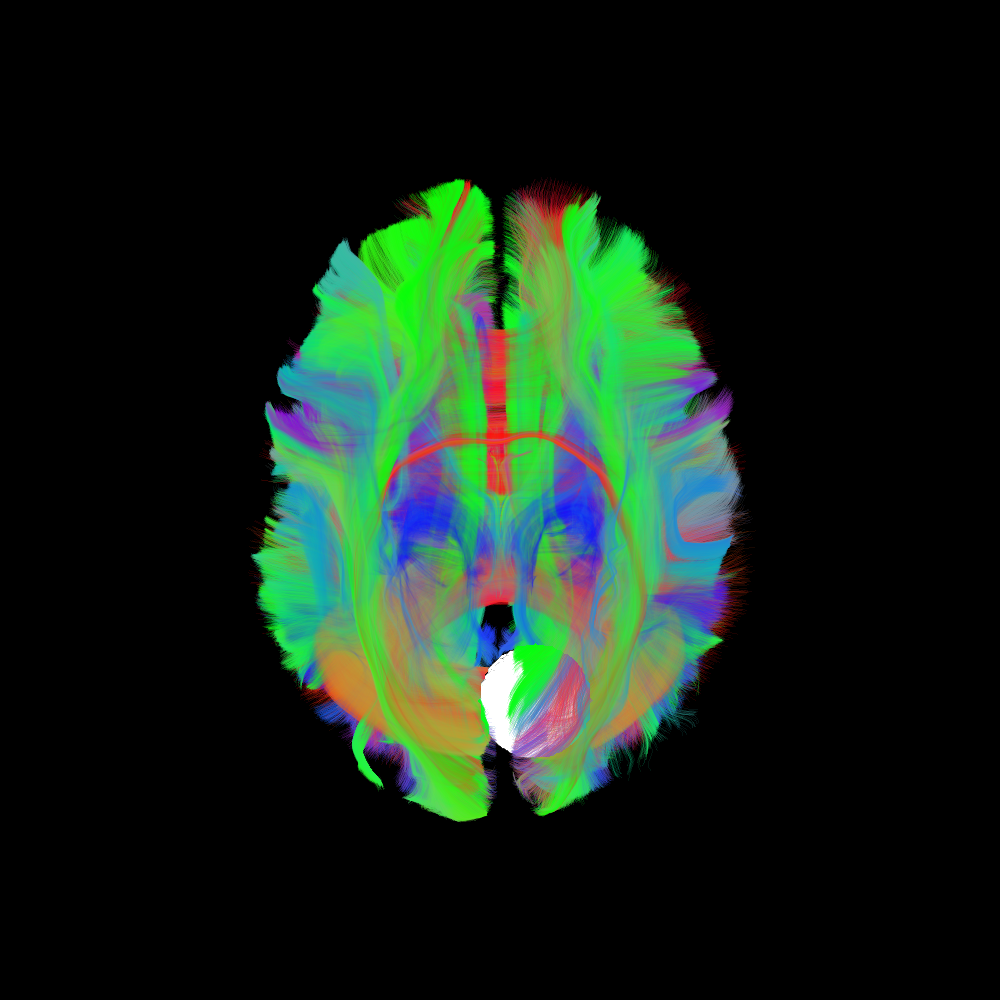

In [6]:
import nibabel as nib
from fury import actor, window, colormap
from IPython.display import Image, display

streamlines = nib.streamlines.load("/tmp/hcp1065_data/hcp1065.tck").streamlines
mask_img = nib.load("/tmp/tutorial_bids/sub-01/ses-01/anat/sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_mask.nii.gz")


mask_actor = actor.contour_from_roi(mask_img.get_fdata(), 
                                    affine=mask_img.affine, 
                                    color=(255, 255, 255),
                                    opacity=1)

colors = colormap.line_colors(streamlines)

tract_actor = actor.line(streamlines, 
                         colors=colors,
                         opacity=0.1)


scene = window.Scene()
scene.add(mask_actor)
scene.add(tract_actor)

window.record(scene=scene, out_path='/tmp/tractogram.png', size=(1000, 1000))
display(Image('/tmp/tractogram.png'))

## Analysis
By filtering the normative tractogram based on the mask image, structural lesion network mapping identifies white matter fiber bundles connected to a specific lesion. By that, we can infer which pathways have been disconnected or disrupted.

What the structural network mapping implementation internally does: 
1. Ensure spatial alignment
2. Compute the voxel-level tract density image (TDI) of full tractogram (amount of streamlines per voxel)
3. Filter the normative tractogram by the lesion mask
4. Compute the TDI of the lesion filtered tractogram and divide the lesion TDI by the original TDI to obtain a disconnection map (% of streamlines connected to the lesion).



Now run the analysis.

In [7]:
!lacuna run snm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_snm_run1/ \
    --connectome-path /tmp/hcp1065_data/hcp1065.tck \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym

The standard run as shown above produces voxel-level disconnectivity maps.

In [60]:
!ls /tmp/outputs_snm_run1/sub-01/ses-01/anat/

sub-01_ses-01_desc-provenance.json
sub-01_ses-01_label-acuteinfarct_summarystatistics_stats.json
sub-01_ses-01_space-MNI152NLin2009cAsym_label-acuteinfarct_mask.nii.gz
sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.json
sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.nii.gz


Visualize the output.

/tmp/ipykernel_369707/741089059.py:6: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  disconnection_map = plotting.plot_stat_map(disconnection_img,


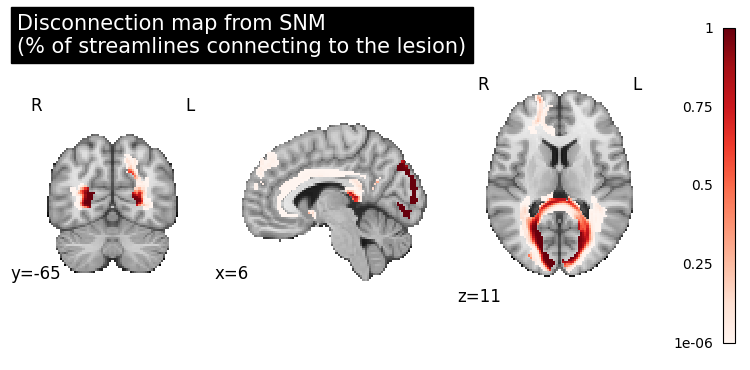

In [8]:
from nilearn import plotting

disconnection_path = '/tmp/outputs_snm_run1/sub-01/ses-01/anat/sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_desc-snm_disconnectionmap.nii.gz'
disconnection_img = nib.load(disconnection_path)

disconnection_map = plotting.plot_stat_map(disconnection_img, 
                       radiological=True, 
                       title="Disconnection map from SNM \n(% of streamlines connecting to the lesion)", 
                       draw_cross=False, 
                       colorbar=True,
                       dim=-0.2,
                       cmap='Reds')

## Obtain ROI-level disconnectivity and disconnectivity matrix

Beyond voxel-level maps, Lacuna covers two further formats of disconnectivity information: region of interest-level disconnectivity scores and a disconnectivity matrix.

These require the `--compute-roi-disconnection` flag as well as definition of a parcellation atlas via `--parcel-atlas`.

In [37]:
!lacuna run snm \
    /tmp/tutorial_bids/ \
    /tmp/outputs_snm_run2/ \
    --connectome-path /tmp/hcp1065_data/hcp1065.tck \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym \
    --compute-disconnectivity-matrix \
    --compute-roi-disconnection \
    --parcel-atlas Schaefer2018_100Parcels7Networks


Matrix outputs comprise four complementary connectivity representations:
1. Disconnectivity matrix – percentage of streamlines disconnected by the lesion
2. Mask connectivity matrix – number of streamlines traversing the lesion mask
3. Intact connectivity matrix – number of remaining streamlines after excluding those passing through the lesion (i.e., total minus mask connectivity)
4. Full connectome matrix – total number of streamlines irrespective of lesion involvement

In [38]:
!ls /tmp/outputs_snm_run2/sub-01/ses-01/anat/*matrix*

/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-disconnectivitypercent_connmatrix.json
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-disconnectivitypercent_connmatrix.tsv
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-fullconnectivitymatrix_connmatrix.json
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-fullconnectivitymatrix_connmatrix.tsv
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-intactconnectivitymatrix_connmatrix.json
/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-i

Visualize the disconnectivity of the visual network

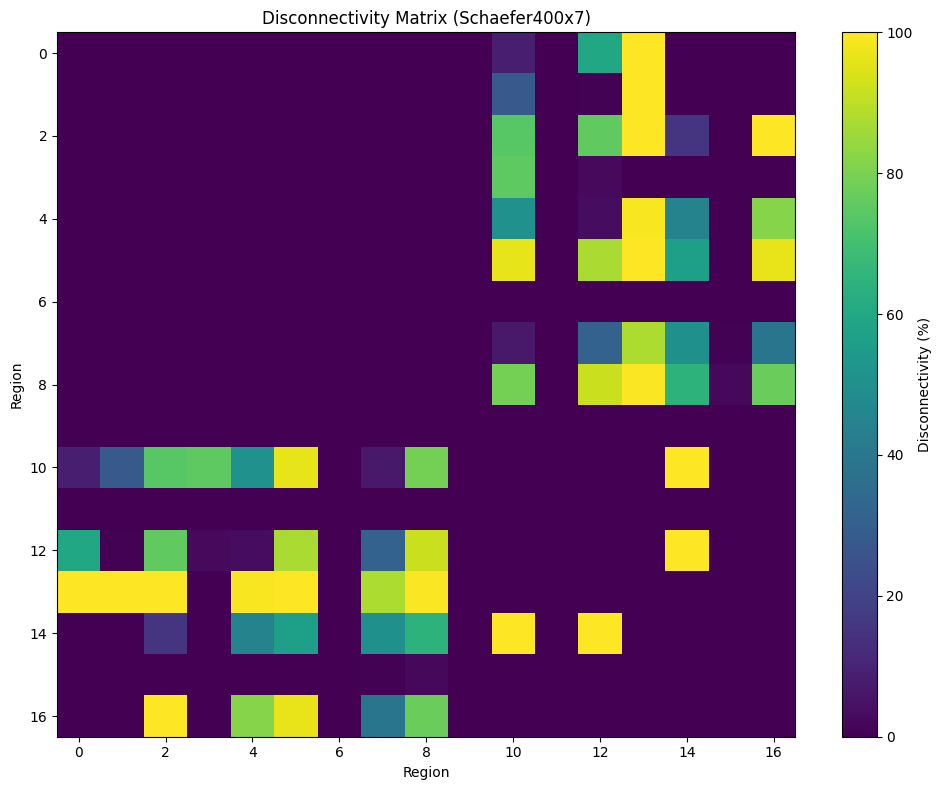

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-disconnectivitypercent_connmatrix.tsv"
mat = pd.read_csv(file_path, sep="\t", header=0, index_col=0)

visual_network_regions = [parc for parc in mat.index if "Vis" in parc]
mat = mat.loc[visual_network_regions, visual_network_regions]
mat = mat.values

plt.figure(figsize=(10, 8))
im = plt.imshow(mat, aspect='auto')
plt.colorbar(im, label="Disconnectivity (%)")

plt.title("Disconnectivity Matrix (Schaefer400x7)")
plt.xlabel("Region")
plt.ylabel("Region")

im.set_clim(0, 100)

plt.tight_layout()
plt.show()

Visualize the region of interest-level data on the cortical surface with [yabplot](https://teanijarv.github.io/yabplot/)

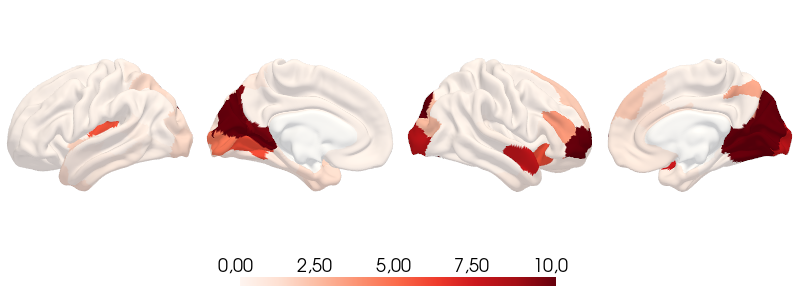

In [ ]:
import yabplot as yab

file_path = "/tmp/outputs_snm_run2/sub-01/ses-01/anat/sub-01_ses-01_label-acuteinfarct_atlas-schaefer2018_desc-100parcels7networks_source-snm_desc-roidisconnection_parcelstats.tsv"

df = pd.read_csv(file_path, sep="\t", index_col=0)
values = df.values.flatten()

yab.plot_cortical(
    data=values,
    atlas='schaefer_100',
    views=['left_lateral', 'left_medial', 'right_lateral', 'right_medial'],
    figsize=(800, 300),
    vminmax=(0,10),
    cmap="Reds"
)